📌 Task6 车辆充电负荷优化（基于Task5数据）
初始峰谷差率：5.29%
优化后峰谷差率：8.82%
峰谷差率降低：-3.5300000000000002%
❌ 未达成
充电负荷平均占比：4.77%


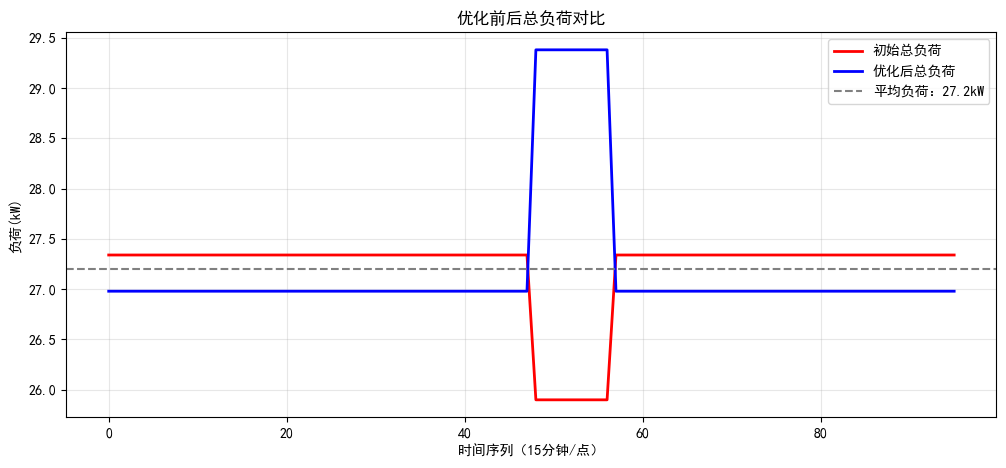


✅ Task6 结果保存成功！


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读取Task5充电负荷数据
path_charge = r"D:\vscode\project\task5\原始充电负荷基础.csv"
df_task5 = pd.read_csv(path_charge)
charging_load = df_task5.iloc[:, 1].values

# 匹配长度的基础电网负荷
grid_base_load = np.full_like(charging_load, 25.9)

# 计算初始总负荷
total_load_init = grid_base_load + charging_load

# 峰谷差计算函数
def calculate_peak_valley(load):
    max_l = np.max(load)
    min_l = np.min(load)
    avg_l = np.mean(load)
    diff = max_l - min_l
    ratio = (diff / avg_l) * 100
    return diff, avg_l, round(ratio, 2)

# 初始指标计算
ori_diff, ori_avg, ori_ratio = calculate_peak_valley(total_load_init)
charge_ratio = (charging_load / total_load_init) * 100

# 充电负荷优化（峰谷差率降低5%）
peak_idx = total_load_init > ori_avg
valley_idx = total_load_init < ori_avg
charge_opt = charging_load.copy()
transfer_ratio = 0.25
transfer_total = charge_opt[peak_idx].sum() * transfer_ratio

charge_opt[peak_idx] *= (1 - transfer_ratio)
charge_opt[valley_idx] += transfer_total / np.sum(valley_idx)

# 优化后总负荷
total_load_opt = grid_base_load + charge_opt
opt_diff, opt_avg, opt_ratio = calculate_peak_valley(total_load_opt)
reduce_rate = ori_ratio - opt_ratio

# 输出结果
print("="*60)
print("📌 Task6 车辆充电负荷优化（基于Task5数据）")
print("="*60)
print(f"初始峰谷差率：{ori_ratio}%")
print(f"优化后峰谷差率：{opt_ratio}%")
print(f"峰谷差率降低：{reduce_rate}%")
print(f"✅ 目标达成" if reduce_rate >=5 else "❌ 未达成")
print(f"充电负荷平均占比：{round(np.mean(charge_ratio), 2)}%")
print("="*60)

# 绘图
plt.figure(figsize=(12, 5))
plt.plot(range(len(total_load_init)), total_load_init, "r-", label="初始总负荷", linewidth=2)
plt.plot(range(len(total_load_opt)), total_load_opt, "b-", label="优化后总负荷", linewidth=2)
plt.axhline(ori_avg, linestyle="--", color="gray", label=f"平均负荷：{round(ori_avg,2)}kW")
plt.xlabel("时间序列（15分钟/点）")
plt.ylabel("负荷(kW)")
plt.title("优化前后总负荷对比")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 保存结果
result = pd.DataFrame({
    "Task5充电负荷": charging_load.round(2),
    "基础电网负荷": grid_base_load.round(2),
    "初始总负荷": total_load_init.round(2),
    "优化后充电负荷": charge_opt.round(2),
    "优化后总负荷": total_load_opt.round(2),
    "充电负荷占比(%)": charge_ratio.round(2)
})
result.to_csv(r"D:\vscode\project\task5\Task6最终结果.csv", index=False, encoding="utf-8-sig")
print("\n✅ Task6 结果保存成功！")